# Campaign Response Classification Model

**Goal:** Predict whether a customer will respond to the next campaign (Response = 1/0)

**Approach:**
1. EDA — understand campaign acceptance rates and class balance
2. Feature engineering — demographics + behavior + cluster (NO past campaign flags as features)
3. Train classifiers — Logistic Regression, Random Forest, Gradient Boosting
4. Evaluate — precision/recall (imbalanced class), AUC, confusion matrix
5. Feature importance — what drives campaign response?
6. Per-cluster predictions — connect back to segmentation

In [26]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, precision_recall_curve,
                             ConfusionMatrixDisplay)
from scipy.stats import chi2_contingency

# Load data with cluster assignments
df = pd.read_csv('../data/preprocessed/david_clustered.csv')
print(f"Shape: {df.shape}")
print(f"Response rate: {df['Response'].mean()*100:.1f}%")
df.head(20)

Shape: (2225, 31)
Response rate: 15.0%


,ID,Cluster,Education,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp2,Complain,Response,Age,Customer_Tenure_Days,Living_With,Children_at_home,Family_Size,Total_Spending,Total_Purchases
0,5524,2,Graduate,58138.0,2012-09-04,58,635,88,546,172,...,0,0,1,57,663,Alone,0,1,1617,22
1,2174,3,Graduate,46344.0,2014-03-08,38,11,1,6,2,...,0,0,0,60,113,Alone,2,3,27,4
2,4141,2,Graduate,71613.0,2013-08-21,26,426,49,127,111,...,0,0,0,49,312,Partner,0,2,776,20
3,6182,0,Graduate,26646.0,2014-02-10,26,11,4,20,10,...,0,0,0,30,139,Partner,1,3,53,6
4,5324,1,PhD,58293.0,2014-01-19,94,173,43,118,46,...,0,0,0,33,161,Partner,1,3,422,14
5,7446,3,Postgraduate,62513.0,2013-09-09,16,520,42,98,0,...,0,0,0,47,293,Partner,1,3,716,20
6,965,1,Graduate,55635.0,2012-11-13,34,235,65,164,50,...,0,0,0,43,593,Alone,1,2,590,17
7,6177,1,PhD,33454.0,2013-05-08,32,76,10,56,3,...,0,0,0,29,417,Partner,1,3,169,8
8,4855,1,PhD,30351.0,2013-06-06,19,14,0,24,3,...,0,0,1,40,388,Partner,1,3,46,5
9,5899,1,PhD,5648.0,2014-03-13,68,28,0,6,1,...,0,0,0,64,108,Partner,2,4,49,1


## 1. Campaign Acceptance Rates

In [27]:
cmp_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']

print('=== CAMPAIGN ACCEPTANCE RATES ===')
for col in cmp_cols:
    accepted = df[col].sum()
    total = len(df)
    print(f'{col}: {accepted}/{total} ({accepted/total*100:.1f}%)')

=== CAMPAIGN ACCEPTANCE RATES ===
AcceptedCmp1: 144/2225 (6.5%)
AcceptedCmp2: 30/2225 (1.3%)
AcceptedCmp3: 163/2225 (7.3%)
AcceptedCmp4: 167/2225 (7.5%)
AcceptedCmp5: 162/2225 (7.3%)
Response: 334/2225 (15.0%)


## 2. Response (Target) Distribution

In [28]:
print('=== RESPONSE (TARGET) DISTRIBUTION ===')
print(df['Response'].value_counts())
print()
print(f"Class balance: {df['Response'].mean()*100:.1f}% accepted, {(1-df['Response'].mean())*100:.1f}% rejected")

=== RESPONSE (TARGET) DISTRIBUTION ===
Response
0    1891
1     334
Name: count, dtype: int64

Class balance: 15.0% accepted, 85.0% rejected


## 3. Customers Who Accepted Multiple Campaigns

In [29]:
df['Total_Accepted'] = df[cmp_cols].sum(axis=1)

print('=== CUSTOMERS WHO ACCEPTED MULTIPLE CAMPAIGNS ===')
print(df['Total_Accepted'].value_counts().sort_index())
print()
print(f"Customers who accepted ZERO campaigns: {(df['Total_Accepted']==0).sum()} ({(df['Total_Accepted']==0).mean()*100:.1f}%)")
print(f"Customers who accepted 1+ campaigns: {(df['Total_Accepted']>=1).sum()} ({(df['Total_Accepted']>=1).mean()*100:.1f}%)")

=== CUSTOMERS WHO ACCEPTED MULTIPLE CAMPAIGNS ===
Total_Accepted
0    1617
1     369
2     142
3      51
4      36
5      10
Name: count, dtype: int64

Customers who accepted ZERO campaigns: 1617 (72.7%)
Customers who accepted 1+ campaigns: 608 (27.3%)


## 4. Cross-Tab: Response vs Past Campaign Acceptance

In [30]:
df['Accepted_Any_Past'] = df[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']].max(axis=1)

print('=== CROSS-TAB: RESPONSE vs PAST CAMPAIGN ACCEPTANCE ===')
print(pd.crosstab(df['Accepted_Any_Past'], df['Response'], margins=True, normalize='index').round(3) * 100)

=== CROSS-TAB: RESPONSE vs PAST CAMPAIGN ACCEPTANCE ===
Response              0     1
Accepted_Any_Past            
0                  91.7   8.3
1                  59.3  40.7
All                85.0  15.0


## 5. Prepare Features for Classification

In [31]:
# Target
y = df['Response']

# Features: demographics + behavior + cluster
# EXCLUDE: ID, Dt_Customer, Response, AcceptedCmp1-5 (leakage), Complain, derived campaign cols
drop_cols = ['ID', 'Dt_Customer', 'Response', 'Complain',
             'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
             'Total_Accepted', 'Accepted_Any_Past']
df_features = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Encode categoricals
df_features = pd.get_dummies(df_features, columns=['Education', 'Living_With'], drop_first=True)

# Train/test split (stratified to preserve 85/15 balance)
X_train, X_test, y_train, y_test = train_test_split(
    df_features, y, test_size=0.3, random_state=42, stratify=y
)

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training: {len(X_train)} samples ({y_train.mean()*100:.1f}% positive)")
print(f"Test:     {len(X_test)} samples ({y_test.mean()*100:.1f}% positive)")
print(f"Features: {X_train.shape[1]}")
print(f"\nFeature list: {df_features.columns.tolist()}")

Training: 1557 samples (15.0% positive)
Test:     668 samples (15.0% positive)
Features: 24

Feature list: ['Cluster', 'Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Age', 'Customer_Tenure_Days', 'Children_at_home', 'Family_Size', 'Total_Spending', 'Total_Purchases', 'Education_PhD', 'Education_Postgraduate', 'Education_Undergraduate', 'Living_With_Partner']


## 6. Train & Compare Models

In [32]:
# Compare 3 classifiers with 5-fold cross-validation
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

print('=== 5-FOLD CROSS-VALIDATION (AUC) ===\n')
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
    cv_results[name] = scores
    print(f'{name}:')
    print(f'  AUC: {scores.mean():.3f} ± {scores.std():.3f}')
    print()

=== 5-FOLD CROSS-VALIDATION (AUC) ===

Logistic Regression:
  AUC: 0.857 ± 0.030

Random Forest:
  AUC: 0.862 ± 0.033

Gradient Boosting:
  AUC: 0.868 ± 0.019



## 7. Evaluate Best Model on Test Set

=== CLASSIFICATION REPORT (Gradient Boosting) ===

              precision    recall  f1-score   support

 No Response       0.90      0.96      0.93       568
    Response       0.66      0.38      0.48       100

    accuracy                           0.88       668
   macro avg       0.78      0.67      0.71       668
weighted avg       0.86      0.88      0.86       668

AUC: 0.875


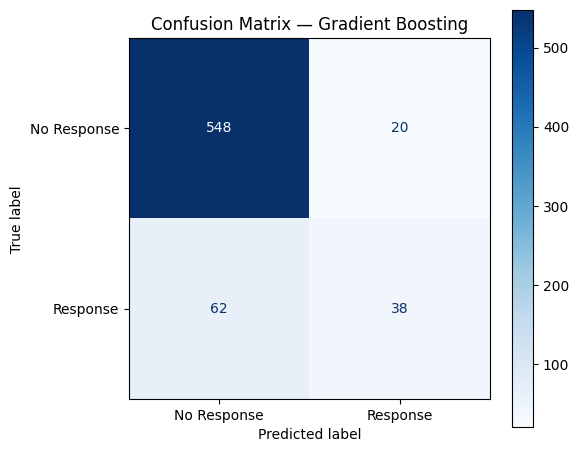

In [33]:
# Train best model on full training set, evaluate on test
best_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train_scaled, y_train)

y_pred = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# Classification report
print('=== CLASSIFICATION REPORT (Gradient Boosting) ===\n')
print(classification_report(y_test, y_pred, target_names=['No Response', 'Response']))
print(f'AUC: {roc_auc_score(y_test, y_proba):.3f}')

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No Response', 'Response'], ax=ax, cmap='Blues')
plt.title('Confusion Matrix — Gradient Boosting')
plt.tight_layout()
plt.show()

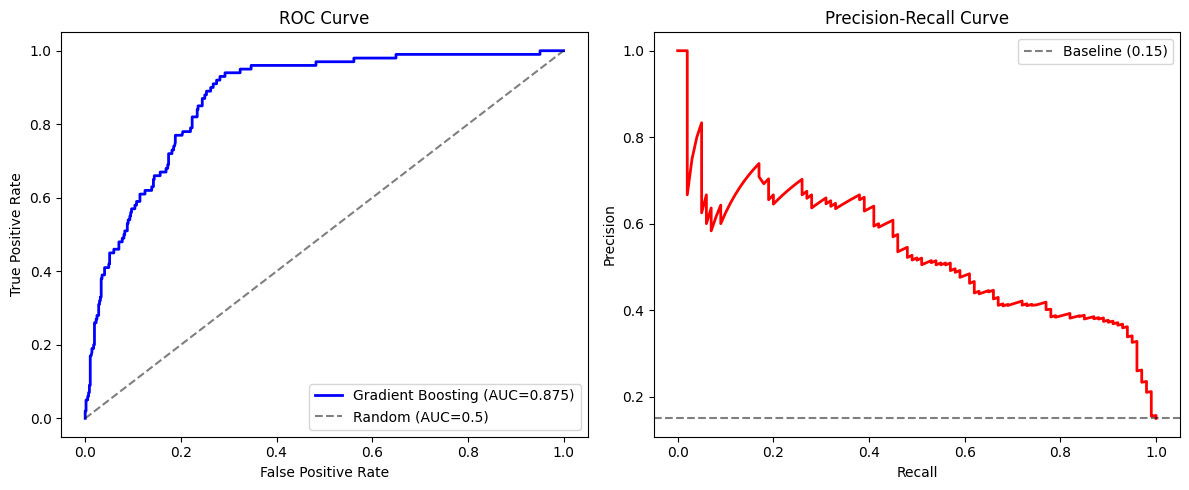

In [34]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr, tpr, 'b-', linewidth=2, label=f'Gradient Boosting (AUC={auc_score:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC=0.5)')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend()

# Precision-Recall curve (more informative for imbalanced data)
precision, recall, _ = precision_recall_curve(y_test, y_proba)
ax2.plot(recall, precision, 'r-', linewidth=2)
ax2.axhline(y=y_test.mean(), color='k', linestyle='--', alpha=0.5, label=f'Baseline ({y_test.mean():.2f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend()

plt.tight_layout()
plt.show()

## 8. Feature Importance — What Drives Campaign Response?

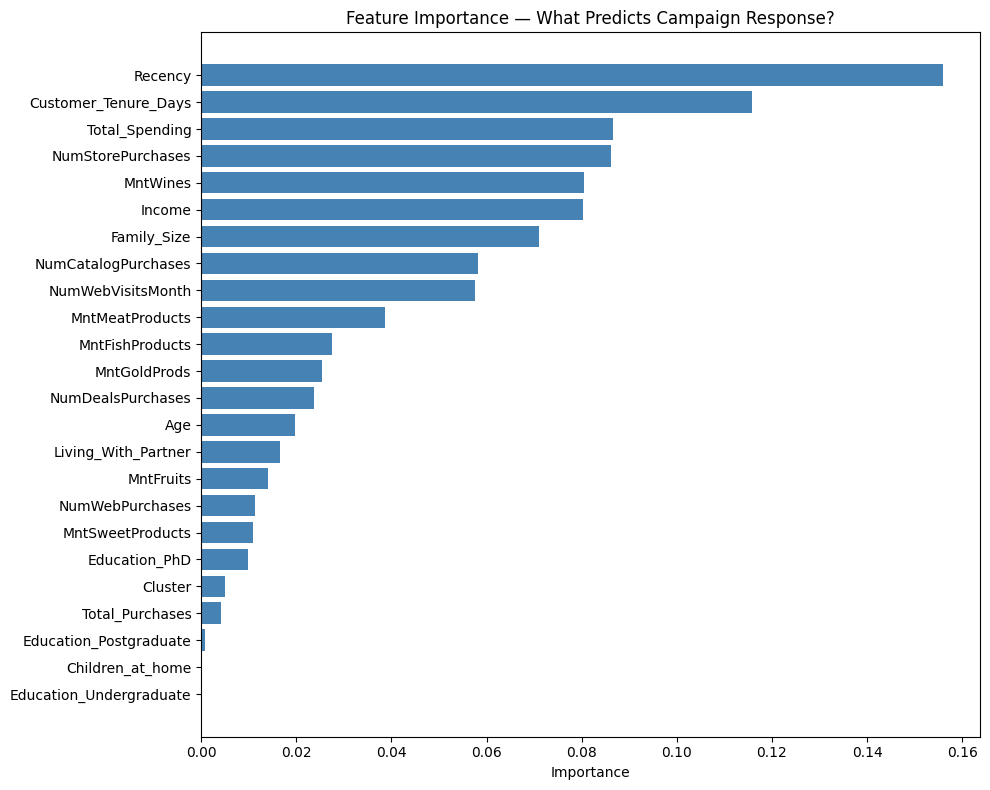


=== TOP 10 FEATURES ===
             Feature  Importance
             Recency    0.155946
Customer_Tenure_Days    0.115801
      Total_Spending    0.086664
   NumStorePurchases    0.086257
            MntWines    0.080505
              Income    0.080259
         Family_Size    0.071070
 NumCatalogPurchases    0.058110
   NumWebVisitsMonth    0.057650
     MntMeatProducts    0.038592


In [35]:
# Feature importance from Gradient Boosting
feature_names = df_features.columns.tolist()
importances = best_model.feature_importances_
feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance — What Predicts Campaign Response?')
plt.tight_layout()
plt.show()

# Top 10
print('\n=== TOP 10 FEATURES ===')
print(feat_imp.sort_values('Importance', ascending=False).head(10).to_string(index=False))

## 9. Response Rate & Model Confidence by Cluster

In [36]:
# Predict probabilities for ALL customers
X_all_scaled = scaler.transform(df_features)
df['response_probability'] = best_model.predict_proba(X_all_scaled)[:, 1]

# Response rate & model confidence by cluster
cluster_perf = df.groupby('Cluster').agg(
    count=('Response', 'count'),
    actual_response_rate=('Response', 'mean'),
    avg_predicted_prob=('response_probability', 'mean'),
    high_prob_customers=('response_probability', lambda x: (x > 0.5).sum())
).round(3)

print('=== CLUSTER PERFORMANCE SUMMARY ===')
print(cluster_perf)

# Chi-squared: are response rate differences across clusters significant?
contingency = pd.crosstab(df['Cluster'], df['Response'])
chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f'\nChi-squared: {chi2:.2f}, p-value: {p_value:.6f}')
print(f'Clusters have significantly different response rates: {"YES" if p_value < 0.05 else "NO"}')

=== CLUSTER PERFORMANCE SUMMARY ===
         count  actual_response_rate  avg_predicted_prob  high_prob_customers
Cluster                                                                      
0          470                 0.106               0.114                   30
1          618                 0.181               0.189                   66
2          566                 0.269               0.246                  118
3          571                 0.035               0.044                    3

Chi-squared: 133.25, p-value: 0.000000
Clusters have significantly different response rates: YES


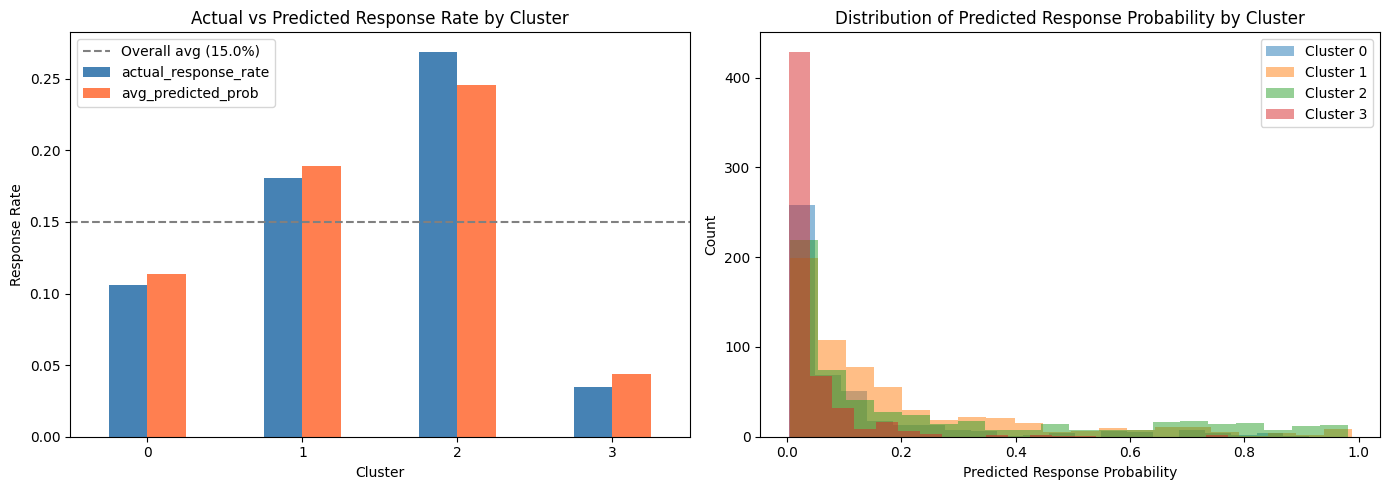

In [37]:
# Visualize: actual vs predicted response by cluster
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

cluster_perf[['actual_response_rate', 'avg_predicted_prob']].plot(kind='bar', ax=ax1, color=['steelblue', 'coral'])
ax1.set_title('Actual vs Predicted Response Rate by Cluster')
ax1.set_ylabel('Response Rate')
ax1.set_xlabel('Cluster')
ax1.axhline(y=df['Response'].mean(), color='gray', linestyle='--', label=f'Overall avg ({df["Response"].mean():.1%})')
ax1.legend()
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

# Distribution of predicted probabilities by cluster
for c in sorted(df['Cluster'].unique()):
    ax2.hist(df[df['Cluster']==c]['response_probability'], bins=20, alpha=0.5, label=f'Cluster {c}')
ax2.set_xlabel('Predicted Response Probability')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of Predicted Response Probability by Cluster')
ax2.legend()

plt.tight_layout()
plt.show()